In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d
from scipy.optimize import root
import importlib
import classy
from scipy.special import sici
from classy import Class
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [2]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'omega_b':0.0223828,
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':0,
'background_verbose':3,
'output':'mTk, vTk, mPk',
'P_k_max_1/Mpc':10,
'z_max_pk':1000,
'format':'class',
}

-----
Now neutrini

In [12]:
nuCDM = Class()
nuCDM.set(common_settings)
# pass input parameters

nuCDM = Class()
nuCDM.set(common_settings)
Mnu= 0.5
nuCDM.set({
    'N_ur': 2.0328,
    # 'N_ncdm':1,
    # 'm_ncdm':Mnu,
    'N_ncdm':3,
    'm_ncdm':f'{Mnu/3},{Mnu/3},{Mnu/3}',
    'ncdm_fluid_approximation':2,
})

print(0.5/93.14/(0.12+0.022+0.5/93.14 ))
print(0.00322085/0.142)
nuCDM.compute()

0.03642753688652386
0.022682042253521127
Running CLASS version v3.2.0
Computing background
 fraction of ncdm is 4.469419e-02 
 -> non-cold dark matter species with i=1 has m_i = 1.666667e-01 eV (so m_i / omega_i =9.314270e+01 eV)
 -> non-cold dark matter species with i=2 has m_i = 1.666667e-01 eV (so m_i / omega_i =9.314270e+01 eV)
 -> non-cold dark matter species with i=3 has m_i = 1.666667e-01 eV (so m_i / omega_i =9.314270e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 1.666667e-01 eV (so m_i / omega_i =9.314270e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold dark matter species with i=2 has m_i = 1.666667e-01 eV (so m_i / omega_i =9.314270e+01 eV)
 -> ncdm species i=2 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 -> non-cold d

0.0704083885988948


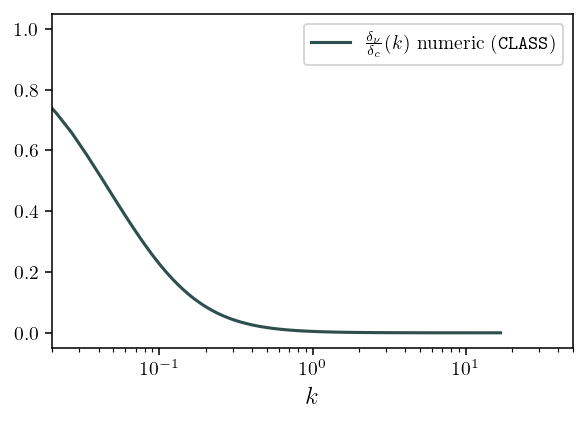

In [13]:
zeval = 0.5
chi_tk_k = nuCDM.get_transfer(z=zeval)

kEval=chi_tk_k['k (h/Mpc)']
d_nu_k=-chi_tk_k['d_ncdm[0]']
d_cdm_k=-chi_tk_k['d_cdm']


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})
plt.figure(figsize=(4.8,3.1), dpi=140)

kJestnu = 5.e-2 * (Mnu/3/0.1) * pow(0.666,1/2)* np.sqrt(nuCDM.Omega0_m()/0.3)

print(kJestnu)
plt.plot(kEval, d_nu_k/d_cdm_k,'darkslategray', linewidth=1.6,label=r'$\frac{\delta_\nu}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
# plt.plot(kEval/kJestnu, g_an(-2*np.log(kEval/(kJestnu))),'limegreen', linestyle='--', linewidth=1.2,label=r'$g(-2\log \frac{k}{k_J})$ ')

plt.xscale('log')
plt.xlabel(r'$k$', fontsize=13)
plt.legend(loc='upper right', fontsize=10)
plt.xlim([2.e-2,5.e1])
# plt.savefig('/home/fverdian/class/soundspeed-scripts/lincompare.pdf', bbox_inches='tight')
plt.show()

---
plot results

In [4]:
k, dcdc22, dcdc22_EdS, dcTc22, dcTc22_EdS, dcdx22, dcdx22_EdS, dcTx22, dcTx22_EdS, dxdx22, dxdx22_EdS, PL_cc, TL_x =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/neutrinos/P22-Mnu1p0-N24000-p0.txt', unpack=True)[:,:70]

k, dcdc13, dcdc13_EdS, dcTc13, dcTc13_EdS, dcdx13, dcdx13_EdS, dcTx13, dcTx13_EdS, dxdx13, dxdx13_EdS, PL_cc, TL_x, dcdx_IR  =np.loadtxt(f'/home/fverdian/class/soundspeed-scripts/numerical-integrals/neutrinos/P13-Mnu1p0-N16000-p0.txt', unpack=True)[:,:70]

fx=0.02268280069076689
def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

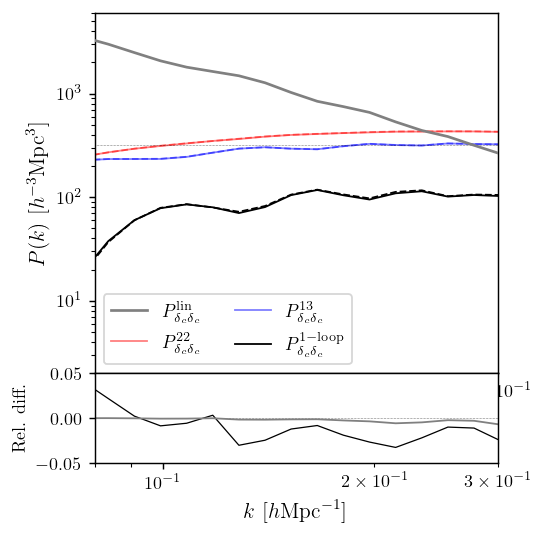

In [28]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), dpi=130, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_c}$', zorder=4)
ax1.plot(k, dcdc22, 'r', label=r'$P^{22}_{\delta_c\delta_c}$', linewidth=1, alpha=0.5)
ax1.plot(k, dcdc22_EdS, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdc13, 'b', label=r'$P^{13}_{\delta_c\delta_c}$', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdc13_EdS, 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, (dcdc22+dcdc13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax1.plot(k, (dcdc22_EdS+dcdc13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.axhline(y=320.18, linestyle=':', color='k', linewidth=0.3)

ax1.set_xscale('log')
ax1.set_yscale('log'),
ax1.set_ylim([2, 6000])
# ax1.set_ylim([-3000, 3000])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

# Lower panel (relative differences)
relative_diff_22 = (dcdc22 - dcdc22_EdS)/(dcdc22  ) #/ dcdc22
relative_diff_13 = (dcdc13 - dcdc13_EdS) /(dcdc13 )# / dcdc13
relative_diff_1l_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (dcdc22 + dcdc13)

# ax2.plot(k, relative_diff_22, 'r', label=r'Rel. diff. $P^{22}$', linewidth=0.7, alpha=0.5, linestyle='-')
# ax2.plot(k, relative_diff_13, 'b', label=r'Rel. diff. $P^{13}$', linewidth=0.7, alpha=0.5, linestyle='-')
ax2.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

relative_diff_Ptot_total = (PL_cc+ (dcdc22 + dcdc13)) / (PL_cc+ dcdc22_EdS + dcdc13_EdS)-1
ax2.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

ax2.set_ylim([-0.05,0.05])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)

ax1.set_xlim([0.08, 0.3])
ax2.set_xlim([0.08, 0.3])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

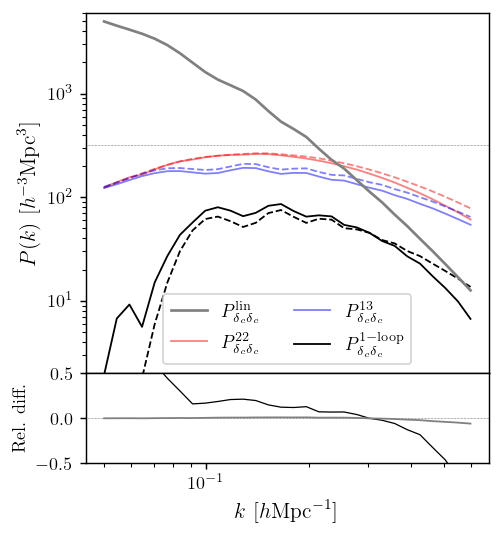

In [29]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), dpi=130, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0})

# Upper panel
ax1.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_c}$', zorder=4)
ax1.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_c}$', linewidth=1, alpha=0.5)
ax1.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13, 'b', label=r'$P^{13}_{\delta_c\delta_c}$', linewidth=1, alpha=0.5)
ax1.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.5)
ax1.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax1.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
ax1.axhline(y=0., linestyle=':', color='k', linewidth=0.3)
ax1.axhline(y=320.18, linestyle=':', color='k', linewidth=0.3)

ax1.set_xscale('log')
ax1.set_yscale('log'),
ax1.set_ylim([2, 6000])
# ax1.set_ylim([-3000, 3000])

ax1.legend(fontsize=10, loc='best', ncol=2)
ax1.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
ax1.tick_params(axis='x', labelbottom=False)

# Lower panel (relative differences)

relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)

ax2.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
ax2.axhline(y=0., linestyle=':', color='k', linewidth=0.3)

relative_diff_Ptot_total = ((dcdx22 + dcdx13)-(dcdx22_EdS + dcdx13_EdS)) / (PL_cc+ dcdc22 + dcdc13)
ax2.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

ax2.set_ylim([-0.5,0.5])
ax2.set_xscale('log')
ax2.set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)
ax2.set_ylabel('Rel. diff.', fontsize=10)

# ax1.set_xlim([0.08, 0.3])
# ax2.set_xlim([0.08, 0.3])

# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_num_dcdchi.pdf', bbox_inches='tight')

plt.show()

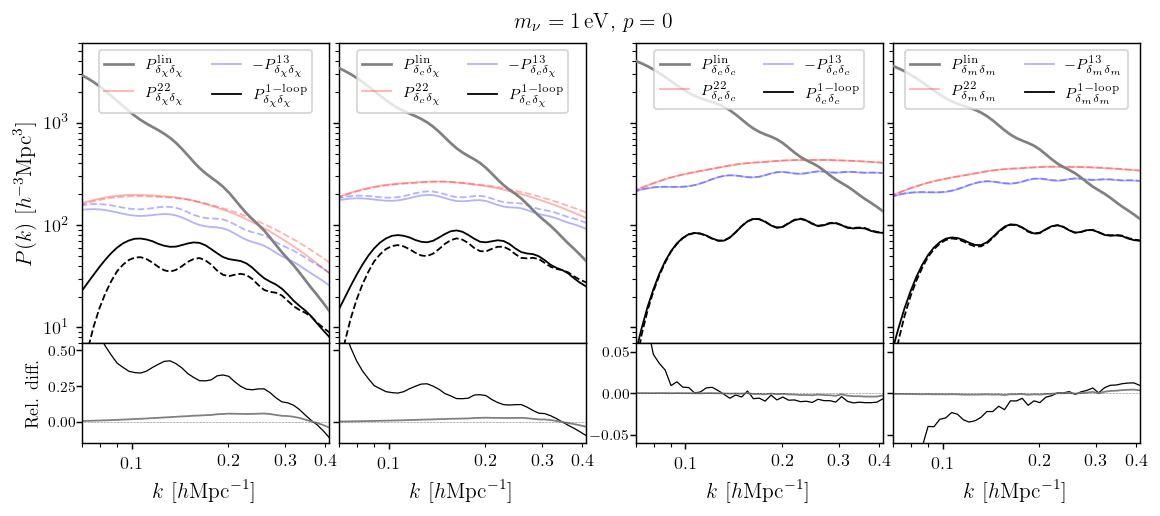

In [6]:
import matplotlib.ticker as ticker

fig, axs = plt.subplots(2, 5, figsize=(10.5, 4.), dpi=130, gridspec_kw={'height_ratios': [3, 1],'width_ratios': [1,1,0.12,1, 1], 'hspace': 0.0, 'wspace':0.05},)

# ------ delta_chi delta_chi
ax = axs[0,0]
ax.plot(k, PL_cc*TL_x*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_\chi\delta_\chi}$', zorder=4)
ax.plot(k, dxdx22, 'r', label=r'$P^{22}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dxdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13, 'b', label=r'$-P^{13}_{\delta_\chi\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dxdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_\chi\delta_\chi}$', linewidth=1)
ax.plot(k, (dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
ax.set_ylabel(r'$P(k)$ $[h^{-3}\mathrm{Mpc}^{3}]$', fontsize=12)
# Lower panel (relative differences)
ax = axs[1,0]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (PL_cc*TL_x*TL_x+ dxdx22 + dxdx13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')
ax.set_ylabel('Rel. diff.', fontsize=10)

# ------ delta_c delta_chi
ax = axs[0,1]
ax.plot(k, PL_cc*TL_x, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_\chi}$', zorder=4)
ax.plot(k, dcdx22, 'r', label=r'$P^{22}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdx22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13, 'b', label=r'$-P^{13}_{\delta_c\delta_\chi}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdx13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdx22+dcdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_\chi}$', linewidth=1)
ax.plot(k, (dcdx22_EdS+dcdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,1]
relative_diff_1l_total = ((dcdx22 + dcdx13) - (dcdx22_EdS + dcdx13_EdS)) / (dcdx22 + dcdx13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (PL_cc*TL_x+ (dcdx22 + dcdx13)) / (PL_cc*TL_x+ dcdx22_EdS + dcdx13_EdS)-1
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_c delta_c
ax = axs[0,3]
ax.plot(k, PL_cc, 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_c\delta_c}$', zorder=4)
ax.plot(k, dcdc22, 'r', label=r'$P^{22}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, dcdc22_EdS, 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13, 'b', label=r'$-P^{13}_{\delta_c\delta_c}$', linewidth=1, alpha=0.3)
ax.plot(k, -dcdc13_EdS, 'b--', linewidth=1, alpha=0.3)
ax.plot(k, (dcdc22+dcdc13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_c\delta_c}$', linewidth=1)
ax.plot(k, (dcdc22_EdS+dcdc13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,3]
relative_diff_1l_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (dcdc22 + dcdc13)
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = ((dcdc22 + dcdc13) - (dcdc22_EdS + dcdc13_EdS)) / (PL_cc+ dcdc22 + dcdc13)
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')

# ------ delta_m delta_m
ax = axs[0,4]
ax.plot(k, PL_cc*mm(1,TL_x, TL_x**2), 'gray', linewidth=1.5, label='$P^{\mathrm{lin}}_{\delta_m\delta_m}$', zorder=4)
ax.plot(k, mm(dcdc22,dcdx22,dxdx22), 'r', label=r'$P^{22}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22_EdS,dcdx22_EdS,dxdx22_EdS) , 'r--', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13,dcdx13,dxdx13), 'b', label=r'$-P^{13}_{\delta_m\delta_m}$', linewidth=1, alpha=0.3)
ax.plot(k, -mm(dcdc13_EdS,dcdx13_EdS,dxdx13_EdS), 'b--', linewidth=1, alpha=0.3)
ax.plot(k, mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13), 'k', label=r'$P^{\mathrm{1-loop}}_{\delta_m\delta_m}$', linewidth=1)
ax.plot(k, mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS), 'k--', linewidth=1)
# Lower panel (relative differences)
ax = axs[1,4]
relative_diff_1l_total = ((dxdx22 + dxdx13) - (dxdx22_EdS + dxdx13_EdS)) / (dxdx22 + dxdx13)
relative_diff_1l_total = mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS)/mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13)-1
ax.plot(k, relative_diff_1l_total, 'k', linewidth=0.7, linestyle='-')
relative_diff_Ptot_total = (mm(dcdc22_EdS+dcdc13_EdS,dcdx22_EdS+dcdx13_EdS,dxdx22_EdS+dxdx13_EdS) - mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))/ (PL_cc*mm(1,TL_x, TL_x**2)+mm(dcdc22+dcdc13,dcdx22+dcdx13,dxdx22+dxdx13))
ax.plot(k, relative_diff_Ptot_total, 'gray', linewidth=1., linestyle='-')


for ax in axs.flat:
    ax.set_xscale('log')
    ax.set_xlim([0.07,0.41])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}"))
    ax.xaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f"{x:g}" if x>0.09 else ""))

for i in [0,1,3,4]:
    axs[0,i].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axs[0,i].legend(fontsize=8, loc='upper center', ncol=2)
    axs[0,i].set_ylim([7e0,6.e3])
    axs[0,i].set_yscale('log')
    axs[1,i].axhline(y=0., linestyle=':', color='k', linewidth=0.3)
    axs[1,i].set_xlabel(r'$k$ $[h\mathrm{Mpc}^{-1}]$', fontsize=12)

for i in [0,1]:
    axs[1,i].set_ylim([-0.15,0.55])
for i in [3,4]:
    axs[1,i].set_ylim([-0.06,0.06])

for com in [(0,1),(1,1),(0,4),(1,4),(0,3)]:
    axs[com].tick_params(axis='y', labelleft=False)
axs[0, 2].axis('off')  # Turn off the top blank subplot
axs[1, 2].axis('off')  # Turn off the bottom blank subplot

axs[1,0].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside
axs[1,3].tick_params(axis='y',labelsize=8, pad=-0.1)  # Y-axis tick labels inside


fig.text(0.5, 0.92, r'$m_\nu=1\,\mathrm{eV}$, $p=0$', ha='center', va='center', fontsize=12)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/1loop_Mnu0p1_full.pdf', bbox_inches='tight')

plt.show()

In [9]:
print(1/93.14/0.142)

print( np.sqrt(5/9)* 5.e-2 * (1/0.1) * pow(0.666,1/2)* np.sqrt(0.142/h/h/0.3))

0.07560933563588965
0.3085749496668351


---

In [1]:
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels, PLnufromClass

fullt=np.linspace(-6,1, 200)
Mnu=0.5
kref = 5.e-2 * (Mnu/3/0.1) * pow(0.666,1/2)* np.sqrt(nuCDM.Omega0_m()/0.3)

nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.001)
plclass = PLnufromClass(fx=fx, Mnu=Mnu, zeval=0.5)
PLc_int = plclass.PLc_int

NameError: name 'sys' is not defined

(0.001, 1.0)

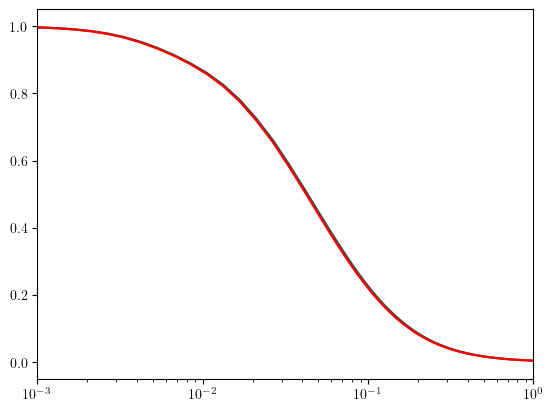

In [25]:
plt.plot(kEval, d_nu_k/d_cdm_k,'darkslategray', linewidth=1.6,label=r'$\frac{\delta_\nu}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
plt.plot(kEval, plclass.g_class(kEval),'r', linewidth=1.6,label=r'$\frac{\delta_\nu}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
plt.xscale('log')
plt.xlim([1.e-3,1.])

In [4]:
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels, PLnufromClass
fx=0.02268280069076689
kref = 5.e-2 * (Mnu/3/0.1) * pow(0.666,1/2)* np.sqrt(nuCDM.Omega0_m()/0.3)

nk = NumKernels(fx=fx, kref=kref, fullt=np.linspace(-6,1, 200), rtol=0.0001, p=2, supprshift=5)
plclass = PLnufromClass(fx=fx, Mnu=Mnu, zeval=0.5)
PLc_int = plclass.PLc_int
def g_numk(k):
    return nk.g_num(-(2+0)*np.log(k/kref))

In [5]:
mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=0.19696
# kplow=0.4
qlist=np.logspace(-4,np.log10(10),30)
F3list_low=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    F3c,_,F3x,_=nk.solve_F3([kplow,qp,mup], return_timedep=False)
    F3list_low.append([F3x/g_numk(kplow),nk.F3_0(kplow,qp,mup), F3c])
F3list_low=np.array(F3list_low).T;



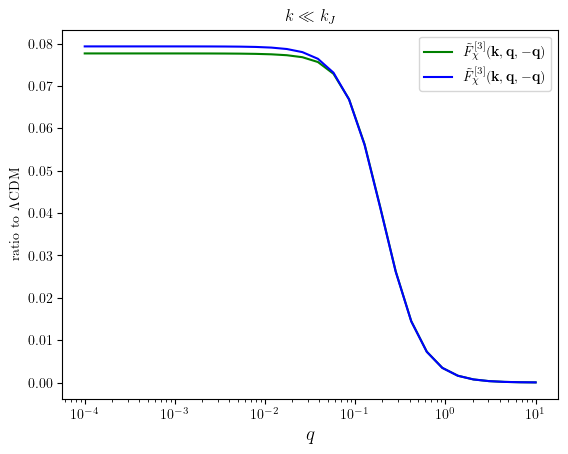

In [6]:
# Second plot
# oldratio = F3list_low[2]
# plt.plot(qlist,F3list_low[2]/F3list_low[1], 'g', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$')
plt.plot(qlist,F3list_low[2], 'g', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$')
plt.plot(qlist,F3list_low[1], 'b', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$')

# plt.plot(qlist,oldratio, 'm', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$')

# plt.text(3.e-3, 0.17, r'$\frac{1}{7}$', color='g', fontsize=9)


# plt.axhline(1, color='k', linestyle=':', linewidth=0.7)
plt.legend()
# plt.ylim([0,None])
plt.title(r'$k\ll k_J$')
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
# plt.yscale('symlog')
plt.xlabel(r'$q$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F23chi.pdf', bbox_inches='tight')
plt.show()